In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import cv2

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.models import Sequential
from keras.layers import Conv2D , MaxPooling2D , Flatten , Dense
from keras.callbacks import EarlyStopping

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
## set SEED

SEED = 42

np.random.seed(SEED);
tf.random.set_seed(SEED)

## set img size
IMAGE_SIZE = (128 , 128)

In [5]:
!ls /content/drive/MyDrive/


'Colab Notebooks'   Document   ffhq_10k     'Jamin doc'
'Deep Learning'     fake       GAN_Project


In [7]:
ffhq_path = '/content/drive/MyDrive/GAN_Project/ffhq_7k'
stylegan2_path = '/content/drive/MyDrive/GAN_Project/StyleGAN2_7k'
REAL = f'{ffhq_path}/train'
FAKE = f'{stylegan2_path}/train'



Some train images: ['15227.png', '13242.png', '16177.png', '17293.png', '16981.png']


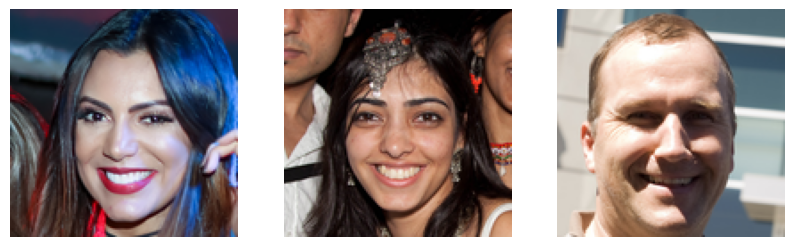

In [9]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# List some train images
train_files = os.listdir(REAL)
print("Some train images:", train_files[:5])

# Display first 3 images
plt.figure(figsize=(10,5))
for i, img_name in enumerate(train_files[:3]):
    img = Image.open(os.path.join(REAL, img_name))
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [10]:
## function for image to FFT



def img_to_FFT(image_path):
  img  = cv2.imread(image_path , cv2.IMREAD_GRAYSCALE)

  # resize image
  img = cv2.resize(img , IMAGE_SIZE)

  ## change int to float and normalize
  img = img.astype('float32') / 255.0

  f = np.fft.fft2(img)
  fshift = np.fft.fftshift(f)
  magnitude_spectrum = np.log(np.abs(fshift))

  return magnitude_spectrum[..., None]  # shape becomes (H, W, 1)


In [14]:
## X and y setup

X = []
y = []



from tqdm import tqdm

real_image_sorted_list = os.listdir(REAL)
real_image_sorted_list_demo = real_image_sorted_list[:800]
fake_image_sorted_list = os.listdir(FAKE)
fake_image_sorted_list_demo = fake_image_sorted_list[:800]

for image_name in tqdm(real_image_sorted_list_demo):
  image_path = os.path.join(REAL , image_name)
  fft_image = img_to_FFT(image_path)
  X.append(fft_image)
  y.append(0)


for image_name in tqdm(fake_image_sorted_list_demo):
  image_path = os.path.join(FAKE , image_name)
  fft_image = img_to_FFT(image_path)
  X.append(fft_image)
  y.append(1)


X = np.array(X)
y = np.array(y)

100%|██████████| 800/800 [03:37<00:00,  3.68it/s]


In [15]:
## shape check

print(f"fft_shapae : {X.shape}")
print(f"y_shape : {y.shape}")

fft_shapae : (1600, 128, 128, 1)
y_shape : (1600,)


In [16]:
# train test split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=SEED , stratify=y)

In [17]:
def build_model():
  model = Sequential()
  model.add(Conv2D(32 , (3,3) , activation='relu' , input_shape=(128,128,1)))
  model.add(MaxPooling2D((2,2)))
  model.add(Conv2D(64 , (3,3) , activation='relu'))
  model.add(MaxPooling2D((2,2)))
  model.add(Conv2D(128 , (3,3) , activation='relu'))
  model.add(MaxPooling2D((2,2)))
  model.add(Flatten())
  model.add(Dense(128 , activation='relu'))
  model.add(Dense(1 , activation='sigmoid'))

  model.compile(optimizer='adam' , loss='binary_crossentropy' , metrics=['accuracy'])


  return model

In [26]:
model = build_model()

early_stopping = EarlyStopping(monitor='val_loss' , patience=5 , restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
history = model.fit(X_train , y_train , epochs=15 ,batch_size=35 , validation_data=(X_test , y_test) , callbacks=[early_stopping])
print("Test eval:", model.evaluate(X_test, y_test, verbose=0))

Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.5115 - loss: 0.9416 - val_accuracy: 0.8875 - val_loss: 0.3559
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9205 - loss: 0.2329 - val_accuracy: 0.8400 - val_loss: 0.3850
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9066 - loss: 0.2139 - val_accuracy: 0.9819 - val_loss: 0.0697
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9728 - loss: 0.0736 - val_accuracy: 0.9769 - val_loss: 0.0647
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9820 - loss: 0.0611 - val_accuracy: 0.9619 - val_loss: 0.0965
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9797 - loss: 0.0592 - val_accuracy: 0.9369 - val_loss: 0.1630
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9754 - loss: 0.0701 - val_accuracy: 0.9300 - val_loss: 0.1864
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9754 - loss: 0.0662 - val_accuracy: 0.9937 - 

In [28]:
from sklearn.metrics import accuracy_score, classification_report



REAL_TEST_DIR = '/content/drive/MyDrive/GAN_Project/ffhq_7k/test'
FAKE_TEST_DIR = "/content/drive/MyDrive/GAN_Project/StyleGAN2_7k/test"

X_test= []
y_test = []

for image_name in tqdm(real_image_sorted_list_demo):
  image_path = os.path.join(REAL , image_name)
  fft_image = img_to_FFT(image_path)
  X_test.append(fft_image)
  y_test.append(0)


for image_name in tqdm(fake_image_sorted_list_demo):
  image_path = os.path.join(FAKE , image_name)
  fft_image = img_to_FFT(image_path)
  X_test.append(fft_image)
  y_test.append(1)


X_test = np.array(X_test)
y_test = np.array(y_test)


print("StyleGAN3 Test Shapes:", X_test.shape, y_test.shape)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print("StyleGAN3 Test Loss:", test_loss)
print("StyleGAN3 Test Accuracy:", test_acc)


y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

print("\nClassification Report (StyleGAN3 Test Set):")
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

100%|██████████| 800/800 [00:07<00:00, 100.43it/s]


StyleGAN3 Test Shapes: (1600, 128, 128, 1) (1600,)
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9976 - loss: 0.0189
StyleGAN3 Test Loss: 0.0151003273203969
StyleGAN3 Test Accuracy: 0.9975000023841858
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Classification Report (StyleGAN3 Test Set):
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       800
        Fake       1.00      1.00      1.00       800

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600

